In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [26]:
df=pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [27]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [28]:
df=df.drop(columns=["Booking_ID"])

In [29]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_Not_Canceled
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,True,False,True
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,True,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,True,False
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,True,False
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,True,False


In [30]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'booking_status_Not_Canceled'],
      dtype='object')

In [31]:
x=df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online']]
y=df['booking_status_Not_Canceled']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [33]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((29020, 27), (7255, 27), (29020,), (7255,))

In [36]:
x=[]
MSE=[]
for i in range(1,21):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy=(TP+TN)/(TP+TN+FP+FN)
    x.append(accuracy)
    mse=mean_squared_error(y_test,y_pred)
    MSE.append(mse)
print(x)
Max=max(x)
print(Max)



[np.float64(0.8111647139903515), np.float64(0.7607167470709856), np.float64(0.8108890420399725), np.float64(0.7880082701585114), np.float64(0.808959338387319), np.float64(0.7976567884217781), np.float64(0.808959338387319), np.float64(0.7993108201240524), np.float64(0.8053756030323914), np.float64(0.7987594762232942), np.float64(0.808959338387319), np.float64(0.8022053756030324), np.float64(0.8068917987594763), np.float64(0.8022053756030324), np.float64(0.8066161268090972), np.float64(0.8044107512060648), np.float64(0.8073053066850447), np.float64(0.8056512749827704), np.float64(0.8044107512060648), np.float64(0.8002756719503791)]
0.8111647139903515


In [37]:

x.index(0.8111647139903515)


0

In [38]:
nn=KNeighborsClassifier(n_neighbors=1)
model=nn.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
accuracy=(TP+TN)/(TP+TN+FP+FN)
ER=1-accuracy
SEN=TP/(TP+FN)
SPE=(TN)/(TN+FP)
print("Accuracy = ",accuracy)
print("Error Rate = ",ER)
print("Sensitivity = ",SEN)
print("Specificity = ",SPE)

Accuracy =  0.8111647139903515
Error Rate =  0.1888352860096485
Sensitivity =  0.8514155817317628
Specificity =  0.730546357615894


In [40]:
x_train
predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([False])

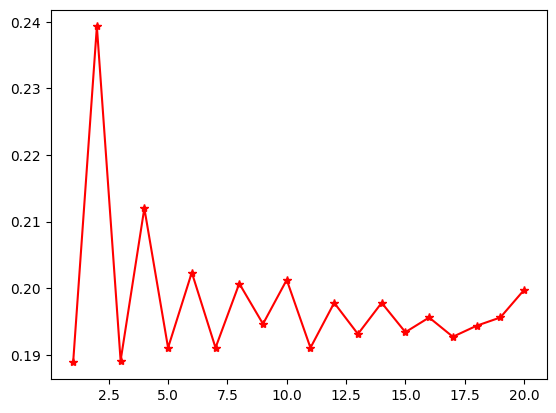

In [41]:
x1=list(range(1,21))
plt.plot(x1,MSE,'*-r')
plt.show()

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [43]:
df=pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [44]:
df.isna().sum()


Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [45]:
df=df.drop(columns=["Booking_ID"])

In [46]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_Not_Canceled
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,True,False,True
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,True,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,True,False
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,True,False
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,True,False


In [47]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'booking_status_Not_Canceled'],
      dtype='object')

In [48]:
x=df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online']]
y=df['booking_status_Not_Canceled']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [49]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((29020, 27), (7255, 27), (29020,), (7255,))

In [57]:
x1=[]
MSE1=[]
for i in range(1,21):
    model=DecisionTreeClassifier(criterion='entropy',max_depth=i,random_state=42)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy=(TP+TN)/(TP+TN+FP+FN)
    x1.append(accuracy)
    mse=mean_squared_error(y_test,y_pred)
    MSE1.append(mse)
Max1=max(x1)
print(Max1)

0.882012405237767


In [58]:
x1.index(0.882012405237767)

13

In [88]:
model=DecisionTreeClassifier(criterion='entropy',max_depth=14,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
accuracy=(TP+TN)/(TP+TN+FP+FN)
ER=1-accuracy
SEN=TP/(TP+FN)
SPE=(TN)/(TN+FP)
print("Accuracy = ",accuracy)
print("Error Rate = ",ER)
print("Sensitivity = ",SEN)
print("Specificity = ",SPE)

Accuracy =  0.882012405237767
Error Rate =  0.11798759476223297
Sensitivity =  0.919611489977268
Specificity =  0.8067052980132451


In [60]:
x_train
predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([ True])

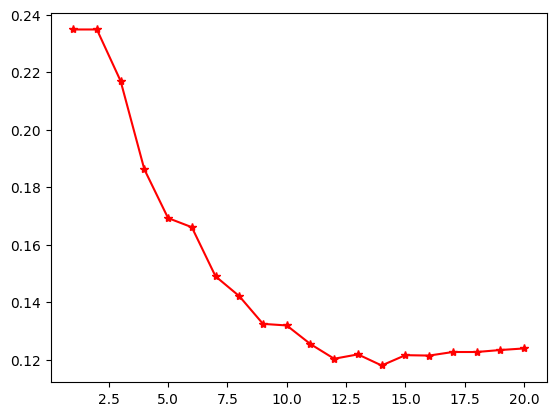

In [62]:
x2=list(range(1,21))
plt.plot(x2,MSE1,'*-r')
plt.show()

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [64]:
df=pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [65]:
df=df.drop(columns=["Booking_ID"])

In [66]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_Not_Canceled
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,True,False,True
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,True,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,True,False
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,True,False
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,True,False


In [67]:
x=df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online']]
y=df['booking_status_Not_Canceled']

In [68]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [69]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((29020, 27), (7255, 27), (29020,), (7255,))

In [83]:
x1=[]
MSE2=[]
for i in range(51,71):
    rf=RandomForestClassifier(n_estimators=i,random_state=42,max_depth=5)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy=(TP+TN)/(TP+TN+FP+FN)
    x1.append(accuracy)
    mse=mean_squared_error(y_test,y_pred)
    MSE2.append(mse)
Max1=max(x1)
print(Max1)

0.8283942108890421


In [84]:
x1.index(0.8283942108890421)

0

In [85]:
rf=RandomForestClassifier(n_estimators=51,random_state=42,max_depth=19)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
accuracy=(TP+TN)/(TP+TN+FP+FN)
ER=1-accuracy
SEN=TP/(TP+FN)
SPE=(TN)/(TN+FP)
print("Accuracy = ",accuracy)
print("Error Rate = ",ER)
print("Sensitivity = ",SEN)
print("Specificity = ",SPE)

Accuracy =  0.8982770503101309
Error Rate =  0.10172294968986906
Sensitivity =  0.9433767307294896
Specificity =  0.8079470198675497


In [86]:
x_train
predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([ True])

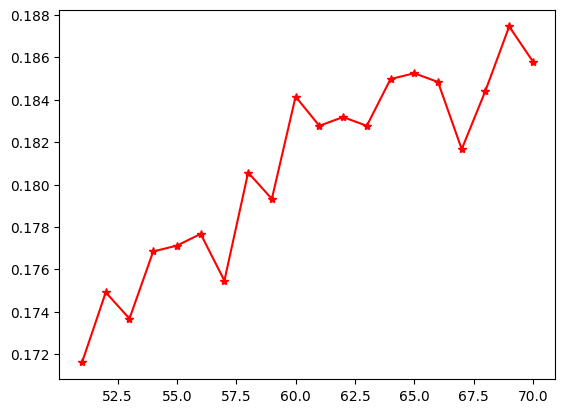

In [87]:
x2=list(range(51,71))
plt.plot(x2,MSE2,'*-r')
plt.show()